In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys
import afterglowpy as grb

from astropy.cosmology import Planck18 as cosmo
from iminuit.cost import LeastSquares
from iminuit import Minuit

In [32]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from tools import flux_to_mag, mag_to_flux
from features import compute_duration_between_first_and_peak, compute_rates, compute_colours
from fit import rescale_filters, fit_light_curve

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Compute features for the orphan afterglow population

In [6]:
# import population
file_po_open = open(f'../data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
orphans = pickle.load(file_po_open)
file_po_open.close()

### Duration between the first detection and the peak

In [7]:
dt_oa = []
for oa in orphans:
    times = np.array(oa['time'])
    mags = np.array(oa['mags'])
    dt_oa.append(compute_duration_between_first_and_peak(times, mags))

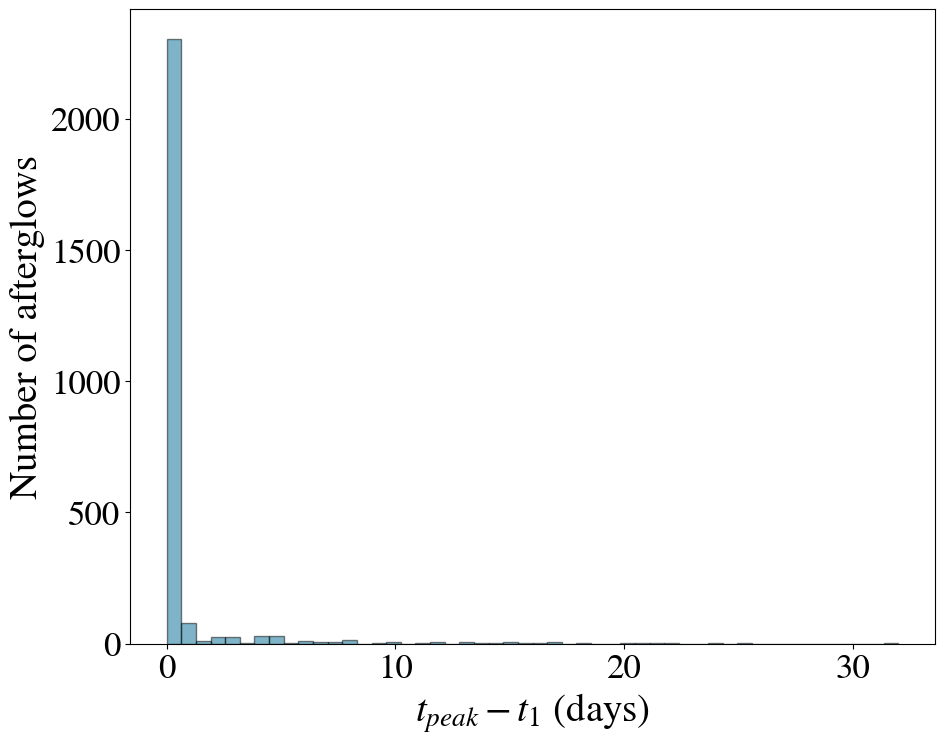

In [8]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(dt_oa, bins=50, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$t_{peak} - t_1$ (days)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
#plt.axvline(x=15, lw=2, color="gray", ls='--', alpha=0.6)
#plt.text(17, 80, "15 days", rotation='vertical', fontsize=20, color='gray')

plt.tight_layout()

#plt.savefig("../figures/dt_features.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

### Increase rates and decrease rates in the first + third third of the decreasing part

In [9]:
rate_i, rate_d1, rate_d3 = [], [], []
for oa in orphans:
    times = np.array(oa['time'])
    mags = np.array(oa['mags'])
    filts = np.array(oa['filt'])
    i, d1, d3 = compute_rates(times, mags, filts)
    rate_i.append(i) 
    rate_d1.append(d1) 
    rate_d3.append(d3)

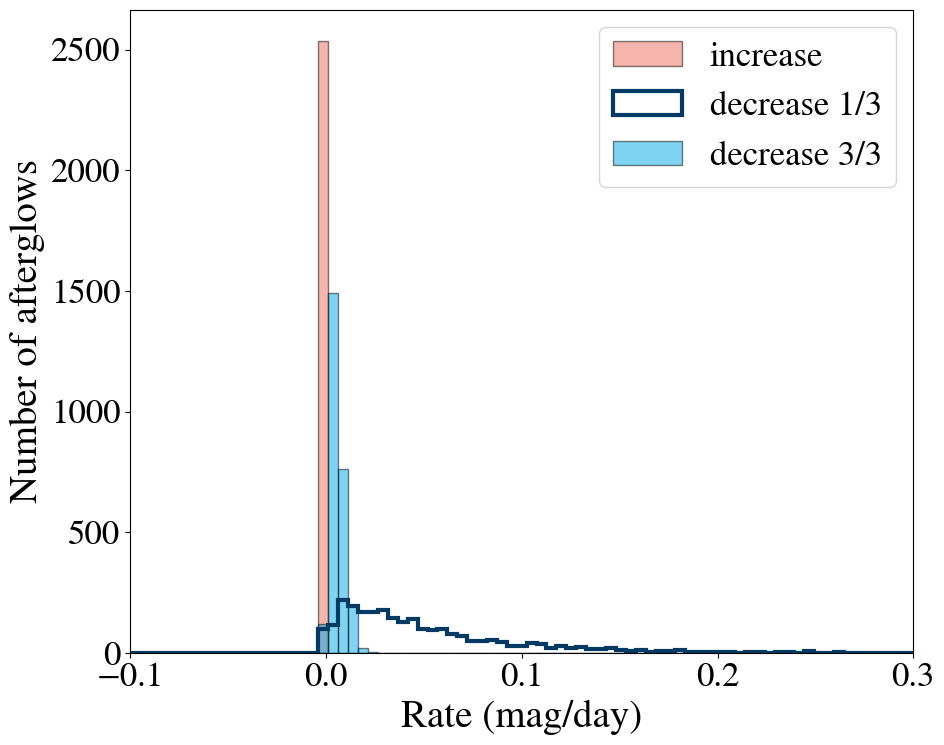

In [11]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

bin_edges = np.linspace(-0.1, 0.3, 80)

plt.hist(rate_i, bins=bin_edges, color='#ed6a5a', alpha=0.5, edgecolor='black', label = 'increase')
plt.hist(rate_d1, bins=bin_edges, histtype='step', color='#013a63', linewidth=3, label = 'decrease 1/3')
plt.hist(rate_d3, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = 'decrease 3/3')

plt.xlabel("Rate (mag/day)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
plt.xlim(-0.1, 0.3)
plt.legend()

plt.tight_layout()

#plt.savefig("../figures/rates_features.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

### g-r and r-i colours

In [12]:
colours = []
for oa in orphans:
    times = np.array(oa['time'])
    mags = np.array(oa['mags'])
    filts = np.array(oa['filt'])
    colours.append(compute_colours(times, mags, filts))

In [13]:
gr, ri = [], []
for pair in colours:
    gr.append(pair[0])
    ri.append(pair[1])

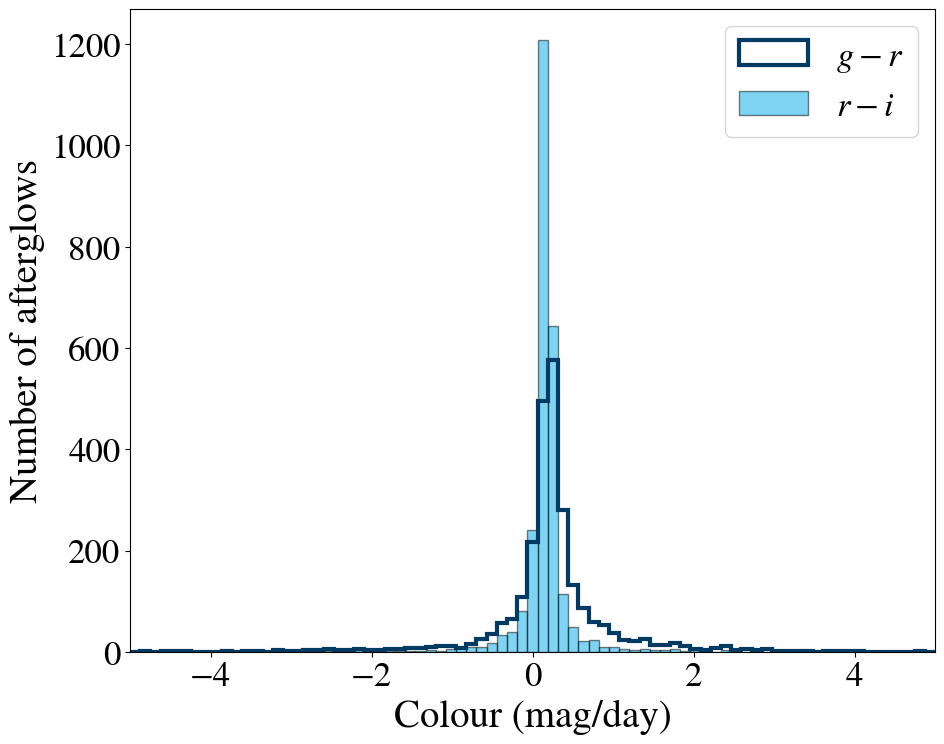

In [14]:
import numpy as np

bin_edges = np.linspace(-5, 5, 80)

plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(gr, bins=bin_edges, histtype='step', color='#013a63', linewidth=3, label = '$g-r$')
plt.hist(ri, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = '$r-i$')

plt.xlabel("Colour (mag/day)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
plt.xlim(-5, 5)
plt.legend()

plt.tight_layout()
#plt.savefig("../figures/colour_features.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [35]:
A = []
B = []
C = []
D = []
chi2 = []

for oa in orphans:
    times = np.array(oa['time'])
    mags = np.array(oa['mags'])
    mags_err = np.array(oa['mags_err'])
    filts = np.array(oa['filt'])
    
    t, m, e = rescale_filters(times, mags, mags_err, filts)
    a, b, c, d, c2 = fit_light_curve(t, m, e, filts)
    
    A.append(a)
    B.append(b)
    C.append(c)
    D.append(d)
    chi2.append(c2)

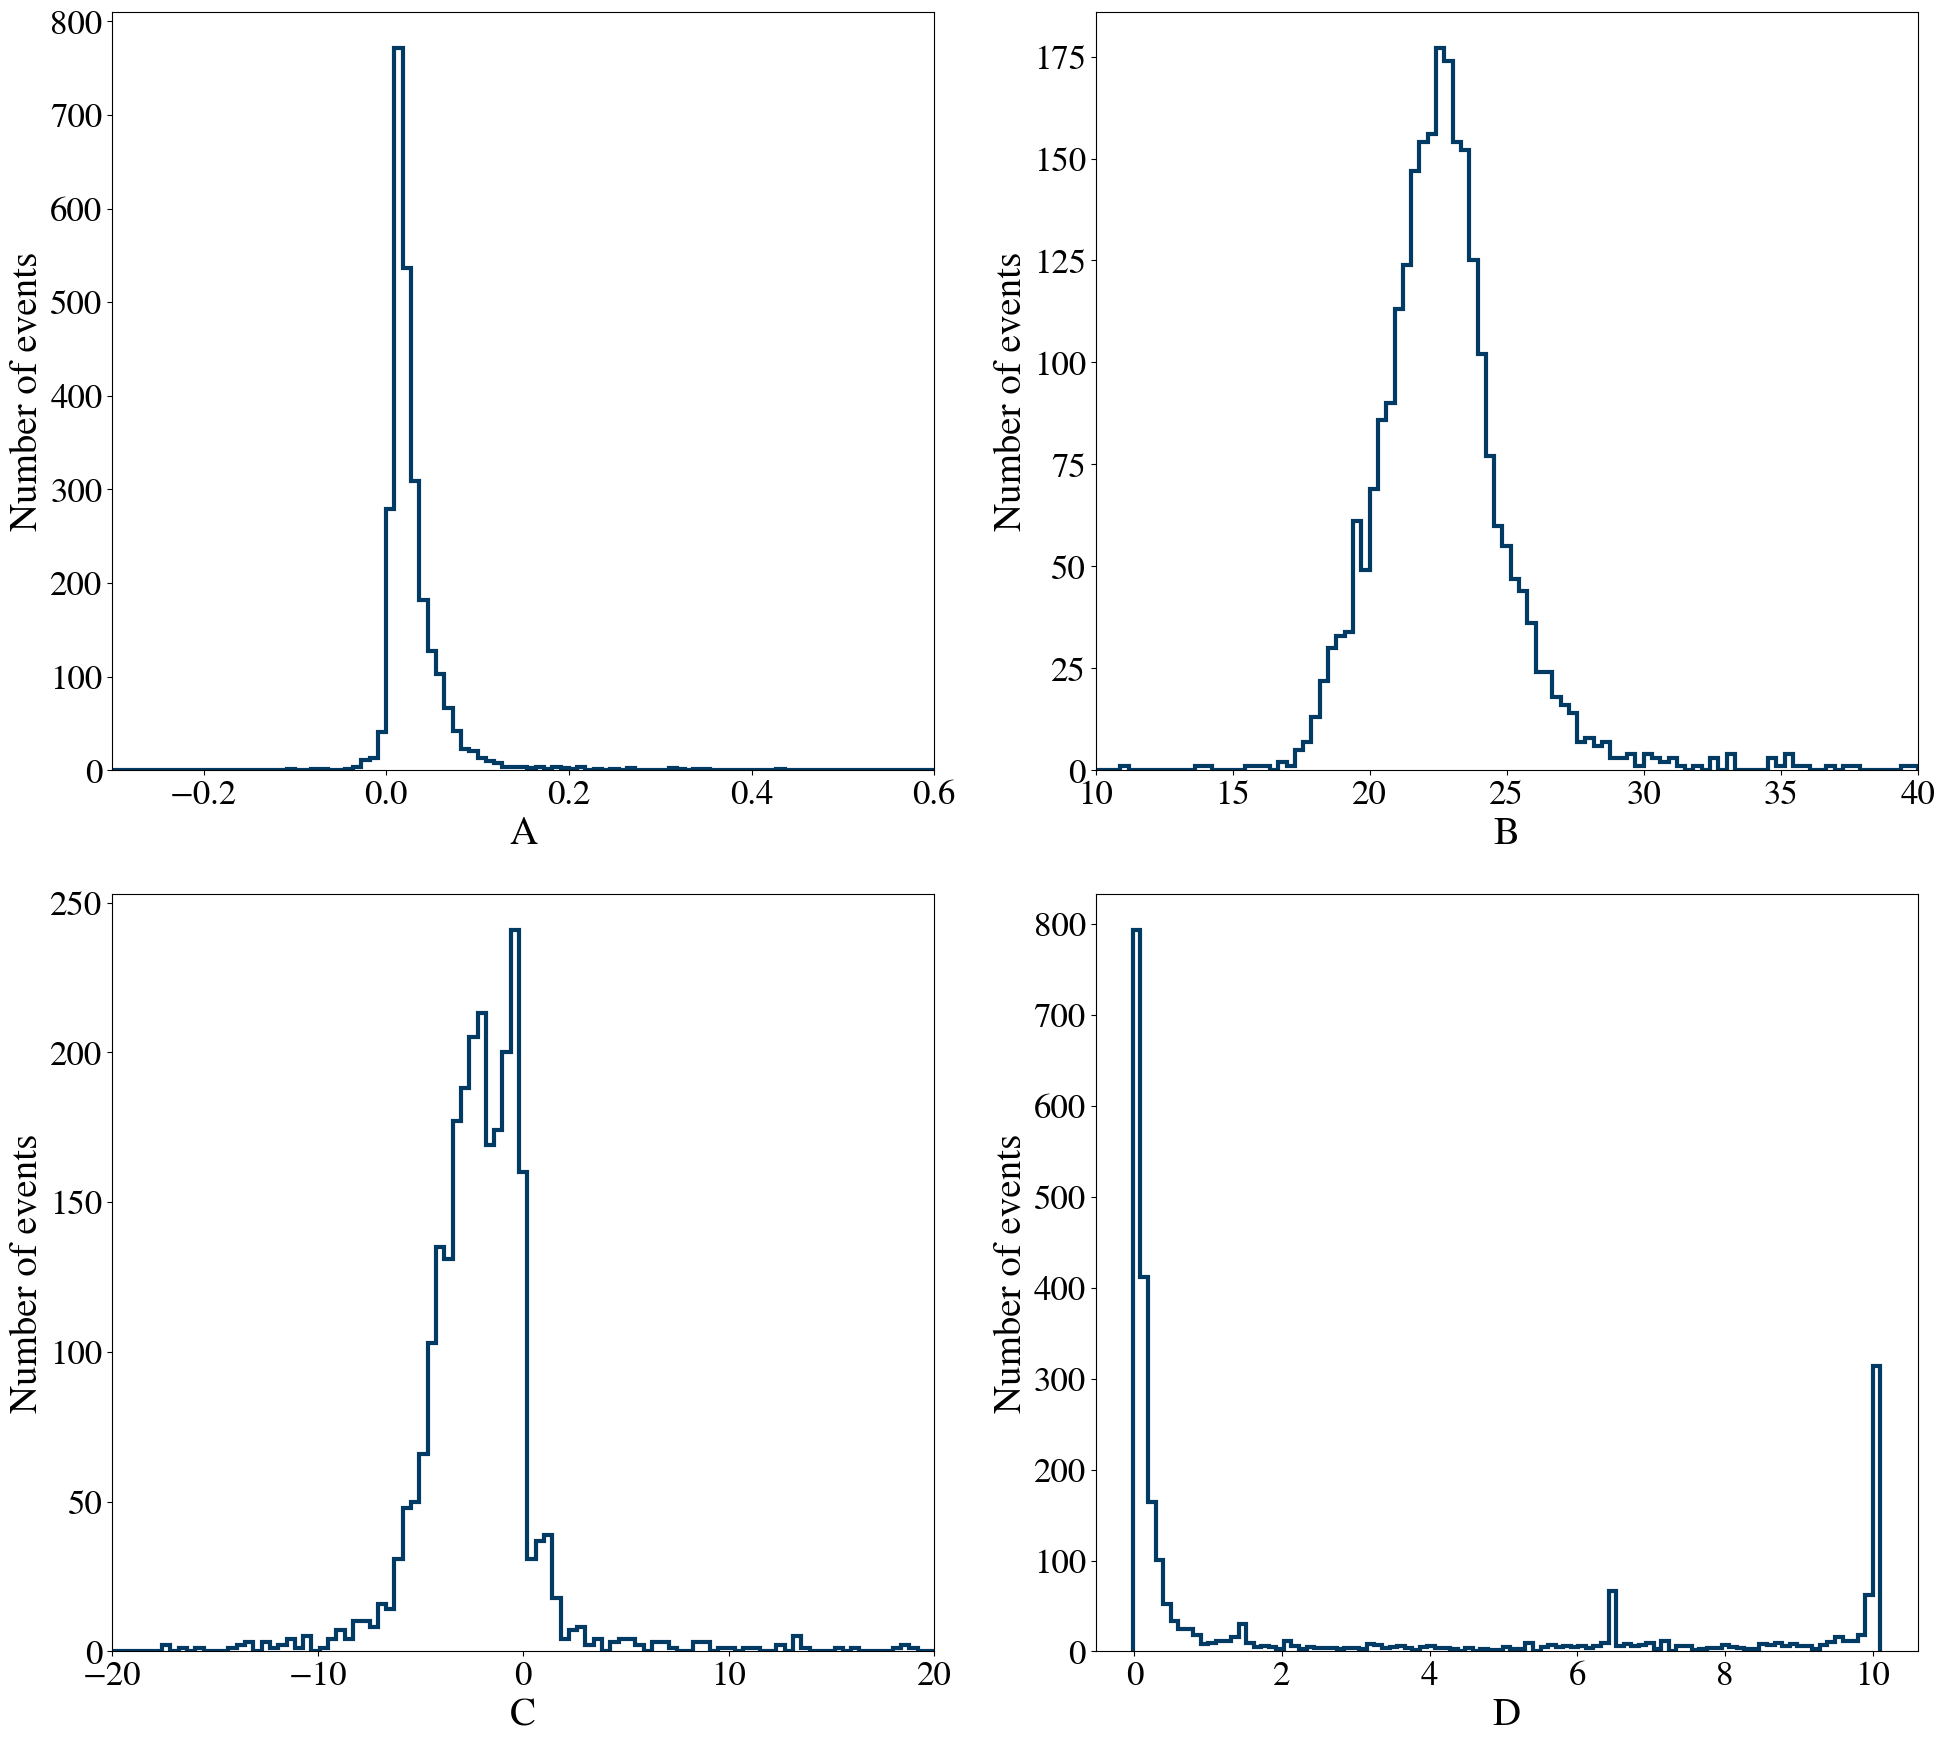

In [41]:
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    ax.set_ylabel('Number of events', fontsize=28)
    ax.set_xlabel(labels[i], fontsize=28)
    if i==0:
        bin_edges = np.linspace(-0.3,0.6,100)
        ax.hist(A, bins=bin_edges, histtype='step', color='#013a63', linewidth=3)
        ax.set_xlim(-0.3,0.6)
    elif i==1:
        bin_edges = np.linspace(10,40,100)
        ax.hist(B, bins=bin_edges, histtype='step', color='#013a63', linewidth=3)
        ax.set_xlim(10,40)
    elif i==2:
        bin_edges = np.linspace(-20,20,100)
        ax.hist(C, bins=bin_edges, histtype='step', color='#013a63', linewidth=3)
        ax.set_xlim(-20,20)
    else:
        bin_edges = np.linspace(-0.02, 10.1, 100)
        ax.hist(D, bins=bin_edges, histtype='step', color='#013a63', linewidth=3)

plt.tight_layout() 

plt.show()

## Comparison with ELAsTiCC

In this notebook, only features for orphan afterglows are computed. For ELAsTiCC events, this is too long so this step is done on the CC-IN2P3.

In [22]:
df_features = pd.read_pickle('../data/orphans_elasticc_features.pkl')

In [24]:
features_oa = df_features[df_features['type']=='orphans']
features_el = df_features[df_features['type']=='elasticc']

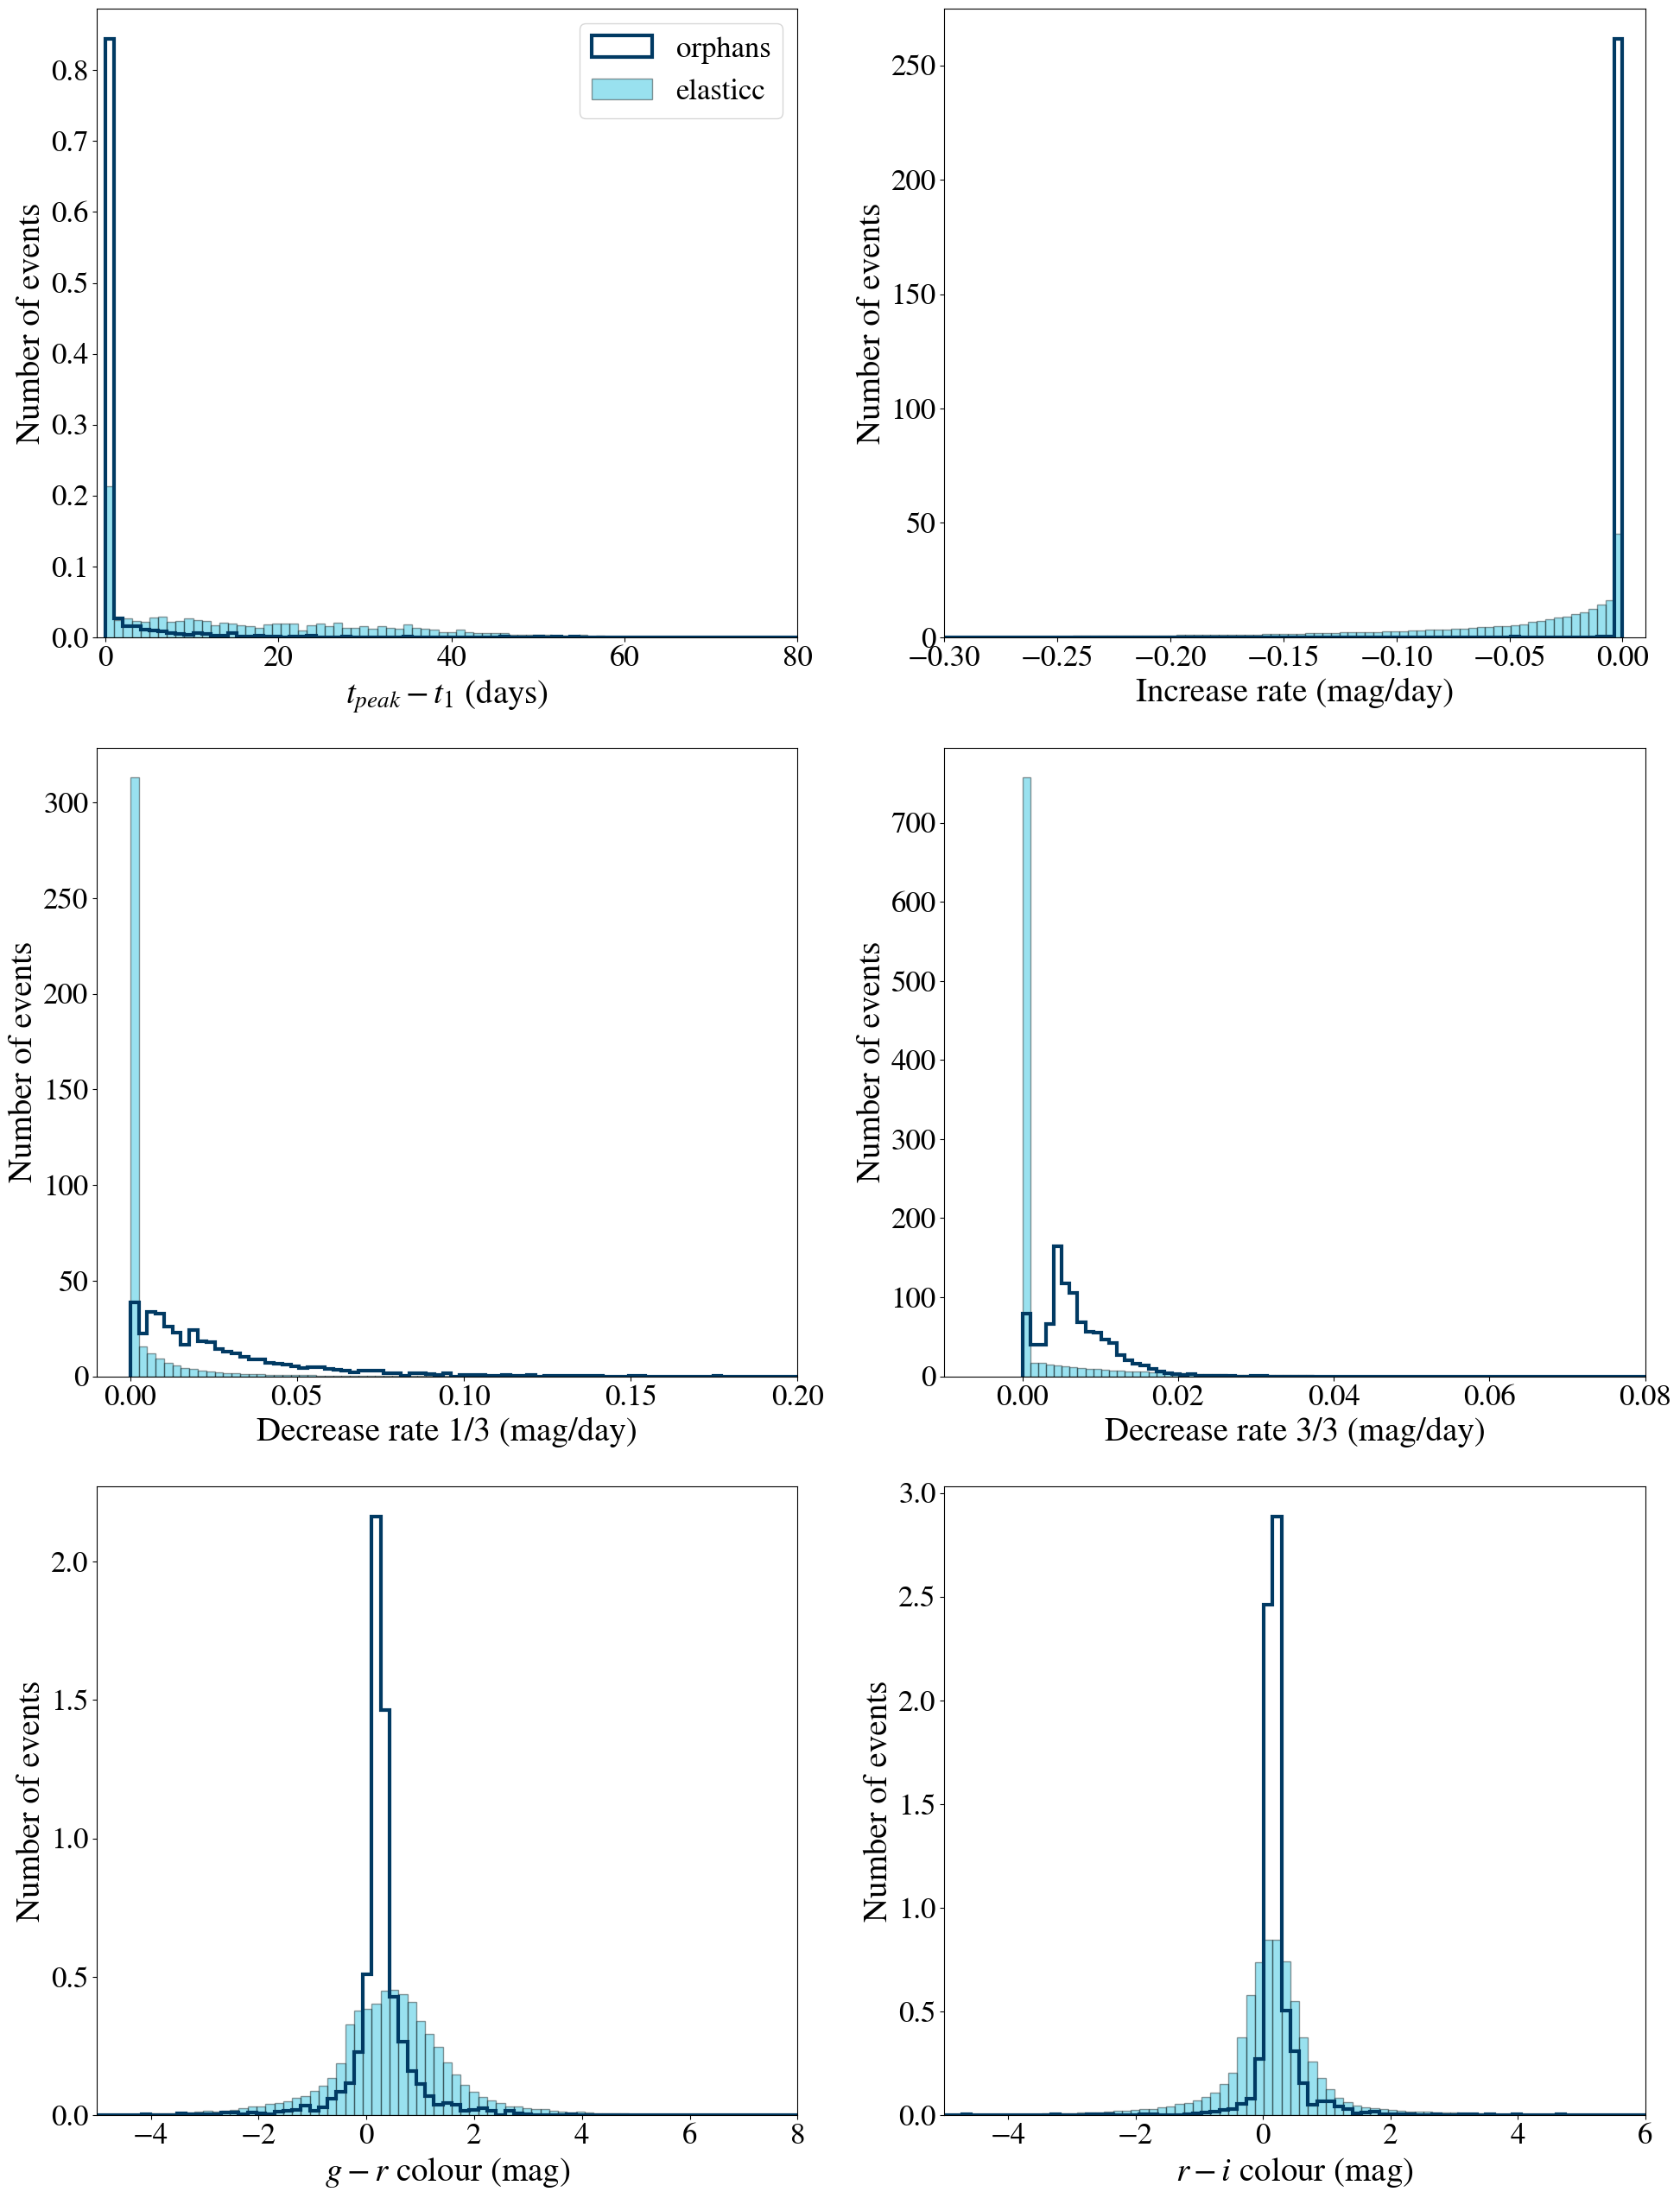

In [27]:
params_o = [features_orphans['duration'], features_orphans['increase_rate'], features_orphans['decrease_rate_1'],
            features_orphans['decrease_rate_3'], features_orphans['g-r'], features_orphans['r-i']]
params_e = [features_elasticc['duration'], features_elasticc['increase_rate'], features_elasticc['decrease_rate_1'], 
            features_elasticc['decrease_rate_3'], features_elasticc['g-r'], features_elasticc['r-i']]
xticks = ['$t_{peak} - t_1$ (days)', 'Increase rate (mag/day)', 'Decrease rate 1/3 (mag/day)', 
          'Decrease rate 3/3 (mag/day)', '$g-r$ colour (mag)', '$r-i$ colour (mag)']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,26), nrows=3, ncols=2)

for i in range(6):
    ax = axes[i//2, i%2]
    ax.set_ylabel('Number of events', fontsize=28)
    ax.set_xlabel(xticks[i], fontsize=28)
    if i==0:
        bin_edges = np.linspace(0,80,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3, label='orphans')
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4, label='elasticc')
        ax.set_xlim(-1,80)
        ax.legend()
    elif i==1:
        bin_edges = np.linspace(-0.3,0.,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-0.3,0.01)
    elif i==2:
        bin_edges = np.linspace(0,0.2,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-0.01,0.2)
    elif i==3:
        bin_edges = np.linspace(0,0.08,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-0.01,0.08)
    elif i==4:
        bin_edges = np.linspace(-5,8,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-5,8)
    elif i==5:
        bin_edges = np.linspace(-5,6,80)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-5,6)

plt.tight_layout() 

#plt.savefig('../figures/orphans_elasticc_features_comparison.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

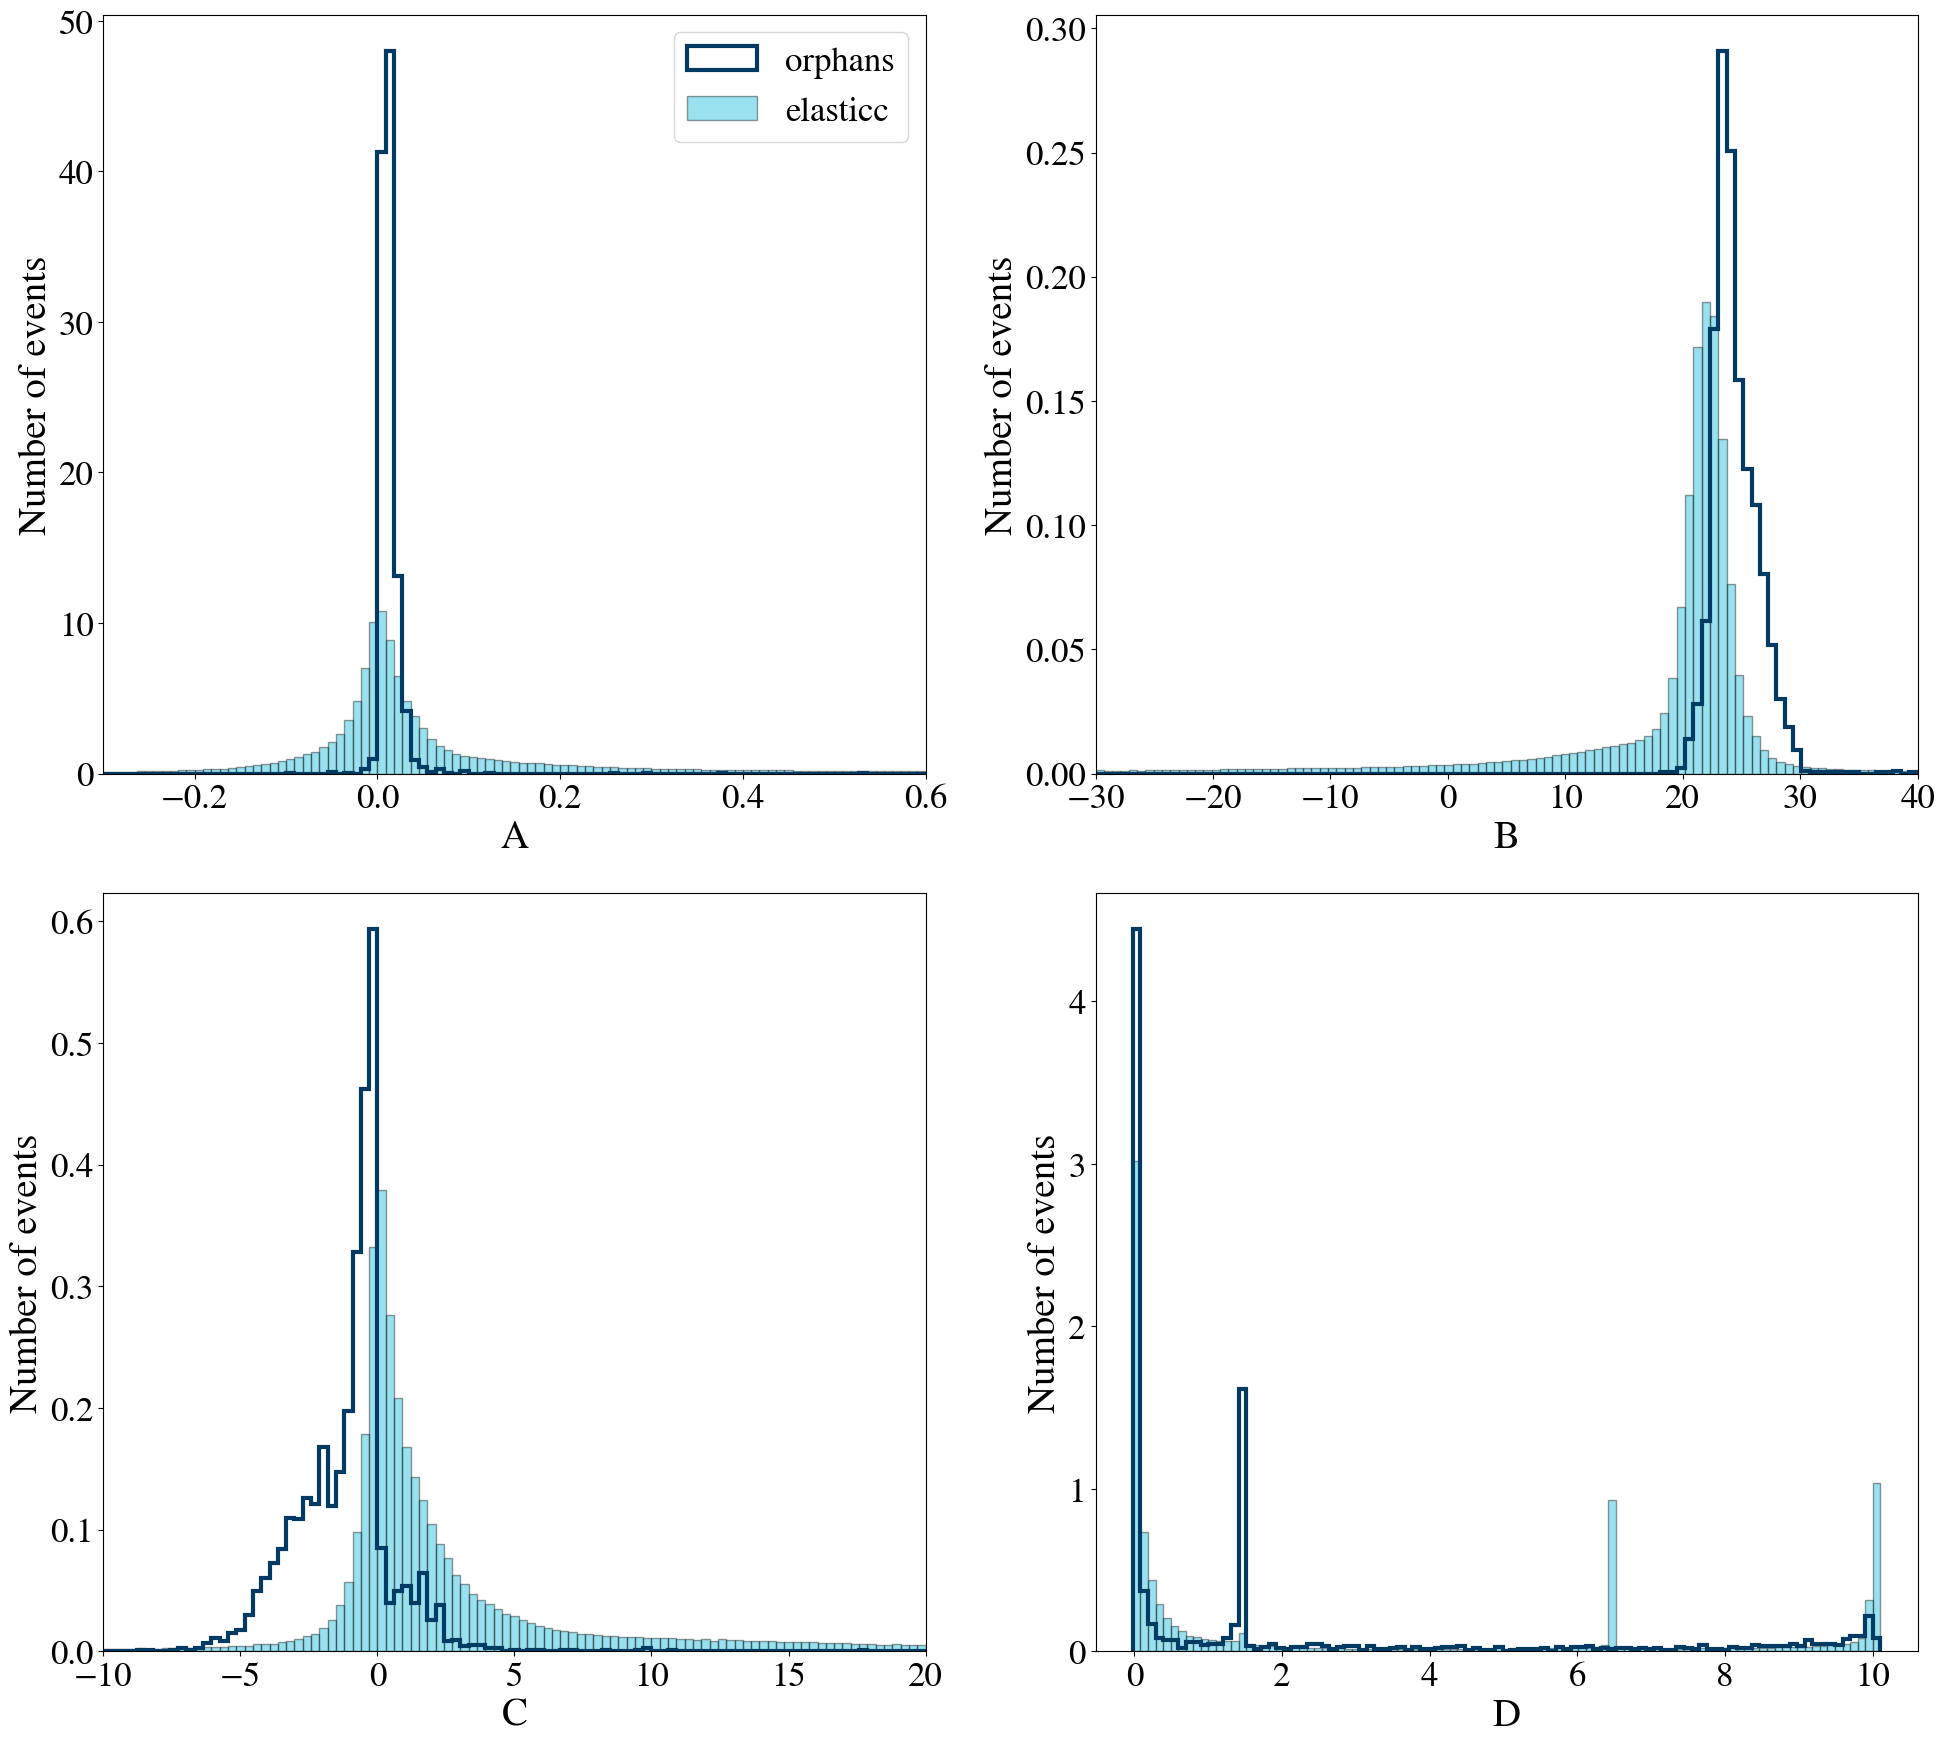

In [25]:
params_o = [features_orphans['A'], features_orphans['B'], features_orphans['C'], features_orphans['D']]
params_e = [features_elasticc['A'], features_elasticc['B'], features_elasticc['C'], features_elasticc['D']]
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    ax.set_ylabel('Number of events', fontsize=28)
    ax.set_xlabel(labels[i], fontsize=28)
    if i==0:
        bin_edges = np.linspace(-0.3,0.6,100)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3, label='orphans')
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4, label='elasticc')
        ax.set_xlim(-0.3,0.6)
        ax.legend()
    elif i==1:
        bin_edges = np.linspace(-30,40,100)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-30,40)
    elif i==2:
        bin_edges = np.linspace(-10,20,100)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)
        ax.set_xlim(-10,20)
    else:
        bin_edges = np.linspace(-0.02, 10.1, 100)
        ax.hist(params_o[i], bins=bin_edges, density=True, histtype='step', color='#013a63', linewidth=3)
        ax.hist(params_e[i], bins=bin_edges, density=True, edgecolor='k', color='#00b4d8', alpha=0.4)

plt.tight_layout() 

#plt.savefig('../figures/elasticc_features_distrib.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()